# تشخيص سرطان القولون والرئة 
مقارنة نماذج التعلم الآلي الكلاسيكية مع معالجة صحيحة لعدم توازن الفئات

## 1. استيراد المكتبات

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("colon and lung cancer dataset.csv")
df

,age,gender,dzgroup,num.co,diabetes,dementia,meanbp,wblc,hrt,resp,...,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlsc
0,63,male,Lung Cancer,0,0,0,97,6.000000,69,22,...,388.00000,1.799805,0.199982,1.199951,141,7.459961,100.0,6.51,2502.0,7.000000
1,60,female,No Cancer,2,0,0,43,17.097656,112,34,...,98.00000,3.500000,1.010000,5.500000,132,7.250000,100.0,6.51,2502.0,1.000000
2,53,female,No Cancer,2,0,0,70,8.500000,88,28,...,231.65625,3.500000,2.199707,2.000000,134,7.459961,100.0,6.51,2502.0,0.000000
3,42,female,Lung Cancer,2,0,0,75,9.099609,88,32,...,333.30000,3.500000,1.010000,0.799927,139,7.400000,100.0,6.51,2502.0,0.000000
4,80,female,No Cancer,1,0,0,59,13.500000,112,20,...,173.31250,3.500000,1.010000,0.799927,143,7.509766,100.0,6.51,2502.0,2.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,66,male,No Cancer,1,0,0,109,7.399414,104,22,...,280.00000,3.699707,0.399963,1.099854,131,7.459961,188.0,21.00,2502.0,0.000000
9101,55,female,No Cancer,1,0,0,43,9.000000,0,8,...,218.50000,3.500000,1.010000,5.899414,135,7.289062,190.0,49.00,0.0,0.000000
9102,70,male,No Cancer,1,0,0,111,8.398438,83,24,...,180.00000,3.500000,0.399963,2.699707,139,7.379883,189.0,60.00,3900.0,2.525391
9103,47,male,No Cancer,1,0,0,99,7.599609,110,24,...,428.56250,1.199951,0.399963,3.500000,135,7.469727,246.0,55.00,2502.0,0.000000


## 2. تحميل البيانات وتنظيفها

In [2]:
# إزالة التكرار
before = df.shape[0]
df = df.drop_duplicates()
print(f"تم حذف {before - df.shape[0]} صف مكرر")

# التأكد من عدم وجود قيم مفقودة
assert df.isna().sum().sum() == 0, "توجد قيم مفقودة تحتاج معالجة"

# توزيع الفئة الهدف (غير متوازن بشكل كبير: 84% / 10% / 6%)
print(df["dzgroup"].value_counts())
print(df["dzgroup"].value_counts(normalize=True) * 100)


تم حذف 0 صف مكرر
dzgroup
No Cancer       7685
Lung Cancer      908
Colon Cancer     512
Name: count, dtype: int64
dzgroup
No Cancer       84.404174
Lung Cancer      9.972543
Colon Cancer     5.623284
Name: proportion, dtype: float64


## 3. EDA  

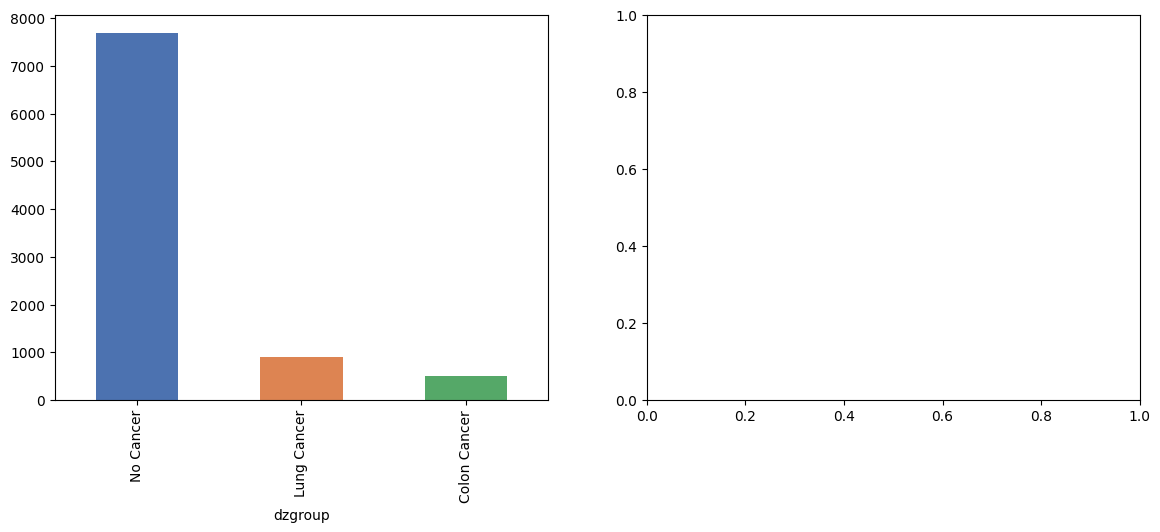

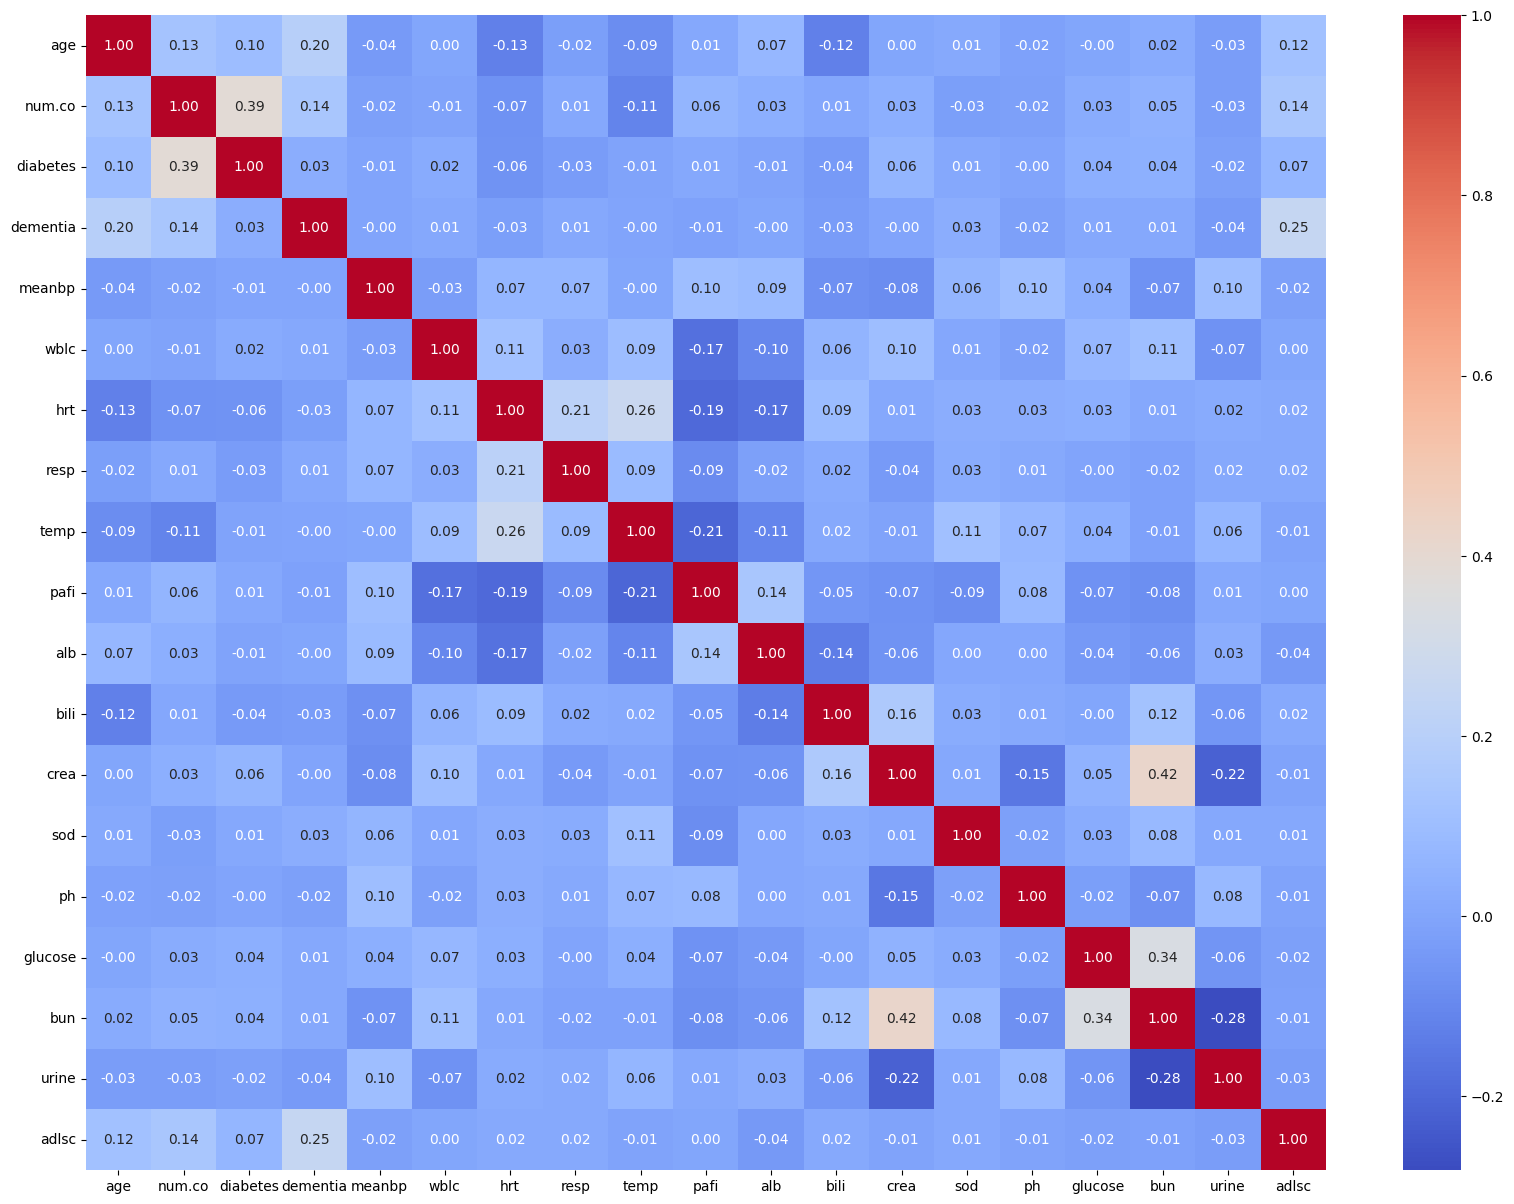

<Figure size 640x480 with 0 Axes>

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df["dzgroup"].value_counts().plot(kind="bar", ax=ax[0], color=["#4c72b0","#dd8452","#55a868"])


# Heat Map
corr_df = df.select_dtypes(include=np.number).corr()
plt.figure(figsize = (20, 15))
sns.heatmap(data = corr_df, annot = True,cmap="coolwarm", fmt=".2f")
plt.show()

plt.tight_layout()
plt.show()


In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# SMOTE: يجب أن يُطبَّق فقط داخل الـ Pipeline لتجنب تسرب البيانات (Data Leakage)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42

## 5. تجهيز البيانات (Encoding + Split + Scaling)

In [5]:
df["gender"] = LabelEncoder().fit_transform(df["gender"])

label_encoder = LabelEncoder()
df["dzgroup"] = label_encoder.fit_transform(df["dzgroup"])
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

X = df.drop("dzgroup", axis=1)
y = df["dzgroup"]

# تقسيم طبقي (Stratified) قبل أي معالجة أخرى لتجنب تسرب البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("توزيع التدريب:", y_train.value_counts().to_dict())
print("توزيع الاختبار:", y_test.value_counts().to_dict())


{'Colon Cancer': 0, 'Lung Cancer': 1, 'No Cancer': 2}
توزيع التدريب: {2: 6148, 1: 726, 0: 410}
توزيع الاختبار: {2: 1537, 1: 182, 0: 102}


## 6. مقارنة النماذج الكلاسيكية

كل نموذج يُبنى داخل `Pipeline` متكامل: `StandardScaler` → `SMOTE` (فقط على بيانات التدريب) → النموذج.
هذا يضمن تقييمًا عادلًا وغير متسرّب للبيانات، ويُستخدم `f1_macro` كمقياس أساسي للمقارنة بدل Accuracy.

In [6]:
candidate_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, max_features="log2", min_samples_split=5,
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300, max_depth=6, learning_rate=0.08,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "SVM (RBF)": SVC(class_weight="balanced", random_state=RANDOM_STATE),
}

results = []
fitted_pipelines = {}

for name, model in candidate_models.items():
    pipe = ImbPipeline(steps=[
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    bal_acc = balanced_accuracy_score(y_test, pred)
    f1_macro = f1_score(y_test, pred, average="macro")
    f1_weighted = f1_score(y_test, pred, average="weighted")

    results.append({
        "Model": name, "Accuracy": acc, "Balanced Accuracy": bal_acc,
        "F1 (macro)": f1_macro, "F1 (weighted)": f1_weighted
    })
    fitted_pipelines[name] = pipe

    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred, target_names=label_encoder.classes_))

results_df = pd.DataFrame(results).sort_values("F1 (macro)", ascending=False)
print(results_df.to_string(index=False))



=== Logistic Regression ===
              precision    recall  f1-score   support

Colon Cancer       0.12      0.60      0.20       102
 Lung Cancer       0.19      0.48      0.27       182
   No Cancer       0.93      0.51      0.66      1537

    accuracy                           0.51      1821
   macro avg       0.41      0.53      0.37      1821
weighted avg       0.81      0.51      0.59      1821


=== Random Forest ===
              precision    recall  f1-score   support

Colon Cancer       0.42      0.31      0.36       102
 Lung Cancer       0.44      0.36      0.39       182
   No Cancer       0.91      0.95      0.93      1537

    accuracy                           0.85      1821
   macro avg       0.59      0.54      0.56      1821
weighted avg       0.84      0.85      0.84      1821


=== Gradient Boosting ===
              precision    recall  f1-score   support

Colon Cancer       0.28      0.50      0.36       102
 Lung Cancer       0.38      0.45      0.42       

In [17]:
import joblib

# استخراج أفضل Pipeline
hist_gb_pipeline = fitted_pipelines["Hist Gradient Boosting"]

# حفظ النموذج بالكامل (Scaler + Model)
joblib.dump(hist_gb_pipeline, "hist_gradient_boosting_pipeline.pkl")

print("Model saved successfully.")

Model saved successfully.


## 7. (Hyperparameter Tuning)

In [15]:


best_model_name = results_df.iloc[0]["Model"]
print("أفضل نموذج بحسب F1-macro:", best_model_name)

param_dist = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__max_depth": [None, 10, 15, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

tuning_pipe = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(class_weight="balanced_subsample",
                                      random_state=RANDOM_STATE, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    tuning_pipe, param_dist, n_iter=20, scoring="f1_macro",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
search.fit(X_train, y_train)

print("أفضل معاملات:", search.best_params_)
print("أفضل F1-macro أثناء التحقق المتقاطع:", search.best_score_)

best_pipe = search.best_estimator_
final_pred = best_pipe.predict(X_test)

print("\n=== أداء النموذج النهائي على بيانات الاختبار ===")
print(f"Accuracy         : {accuracy_score(y_test, final_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, final_pred):.4f}")
print(f"F1 (macro)       : {f1_score(y_test, final_pred, average='macro'):.4f}")
print(f"F1 (weighted)    : {f1_score(y_test, final_pred, average='weighted'):.4f}")
print(classification_report(y_test, final_pred, target_names=label_encoder.classes_))


أفضل نموذج بحسب F1-macro: Hist Gradient Boosting
Fitting 5 folds for each of 20 candidates, totalling 100 fits
أفضل معاملات: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': None}
أفضل F1-macro أثناء التحقق المتقاطع: 0.5637887700375609

=== أداء النموذج النهائي على بيانات الاختبار ===
Accuracy         : 0.8413
Balanced Accuracy: 0.5393
F1 (macro)       : 0.5501
F1 (weighted)    : 0.8363
              precision    recall  f1-score   support

Colon Cancer       0.38      0.33      0.35       102
 Lung Cancer       0.40      0.35      0.37       182
   No Cancer       0.91      0.93      0.92      1537

    accuracy                           0.84      1821
   macro avg       0.56      0.54      0.55      1821
weighted avg       0.83      0.84      0.84      1821



## 8. مصفوفة الارتباك للنموذج النهائي

In [ ]:
cm = confusion_matrix(y_test, final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format="d")
plt.title(f"مصفوفة الارتباك - {best_model_name} (بعد الضبط)")
plt.tight_layout()
plt.show()


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

# =========================
# Focal Loss
# =========================
def focal_loss(gamma=2.0, alpha=0.25):

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)

        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

        ce = -y_true * K.log(y_pred)

        weight = alpha * K.pow(1 - y_pred, gamma)

        return K.mean(K.sum(weight * ce, axis=1))

    return loss

# =========================
# Improved MLP
# =========================
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2, alpha=0.25),
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3377 - loss: 0.9918 - val_accuracy: 0.3240 - val_loss: 0.6848
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3281 - loss: 0.7390 - val_accuracy: 0.3537 - val_loss: 0.6617
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3287 - loss: 0.6849 - val_accuracy: 0.4843 - val_loss: 0.6573
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3387 - loss: 0.6649 - val_accuracy: 0.2037 - val_loss: 0.6560
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3370 - loss: 0.6577 - val_accuracy: 0.6068 - val_loss: 0.6551
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3391 - loss: 0.6554 - val_accuracy: 0.1818 - val_loss: 0.6548
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3347 - loss: 0.6548 - val_accuracy: 0.3899 - val_loss: 0.6548
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3331 - loss: 0.6547 - val_accuracy: 0.

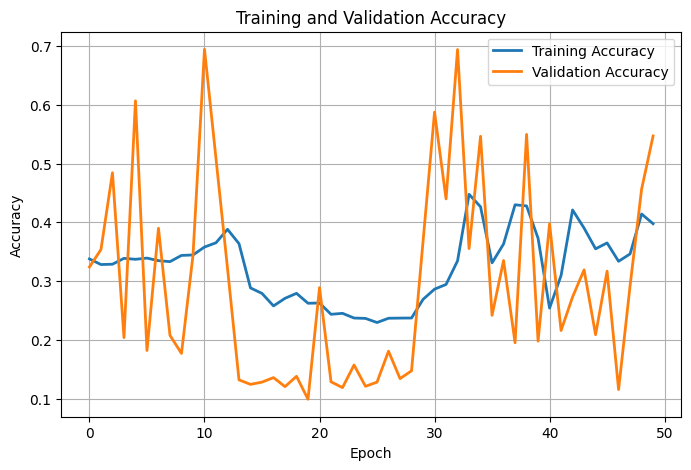

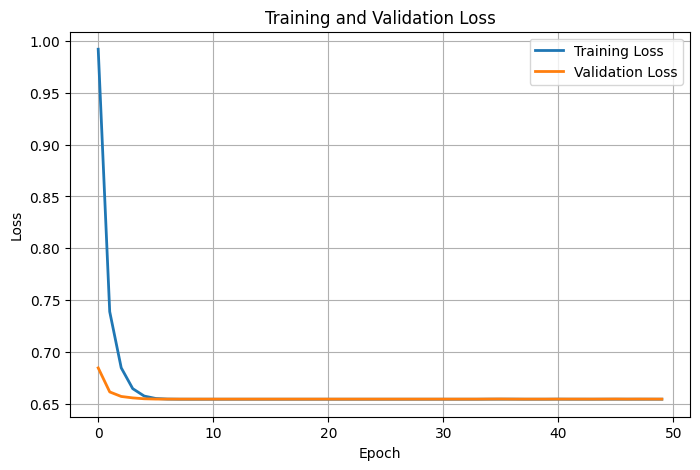

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam

# ==========================
# تجهيز البيانات
# ==========================

X_train_cnn = X_train.to_numpy().astype(np.float32)
X_test_cnn = X_test.to_numpy().astype(np.float32)

X_train_cnn = X_train_cnn.reshape(X_train_cnn.shape[0], X_train_cnn.shape[1], 1)
X_test_cnn = X_test_cnn.reshape(X_test_cnn.shape[0], X_test_cnn.shape[1], 1)

# تحويل y إلى متجه أحادي البعد
if hasattr(y_train, "to_numpy"):
    y_train = y_train.to_numpy().reshape(-1)
    y_test = y_test.to_numpy().reshape(-1)

y_train = y_train.astype("int32")
y_test = y_test.astype("int32")

# عدد الفئات
num_classes = len(np.unique(y_train))

# ==========================
# النموذج
# ==========================

model = Sequential([

    Conv1D(64, 3, activation='relu',
           input_shape=(X_train_cnn.shape[1],1)),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(128, 3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),

    Conv1D(256, 3, activation='relu'),
    BatchNormalization(),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=50,
    batch_size=32
)

Epoch 1/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8310 - loss: 0.5805 - val_accuracy: 0.8440 - val_loss: 0.5569
Epoch 2/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8417 - loss: 0.5413 - val_accuracy: 0.8440 - val_loss: 0.5235
Epoch 3/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8438 - loss: 0.5042 - val_accuracy: 0.8440 - val_loss: 0.8632
Epoch 4/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8436 - loss: 0.4825 - val_accuracy: 0.8440 - val_loss: 0.4804
Epoch 5/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8446 - loss: 0.4708 - val_accuracy: 0.8440 - val_loss: 0.4594
Epoch 6/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8439 - loss: 0.4661 - val_accuracy: 0.8440 - val_loss: 0.4700
Epoch 7/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8442 - loss: 0.4647 - val_accuracy: 0.8440 - val_loss: 0.4472
Epoch 8/50
228/228 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8429 - loss: 0.4605 - val_accuracy: 

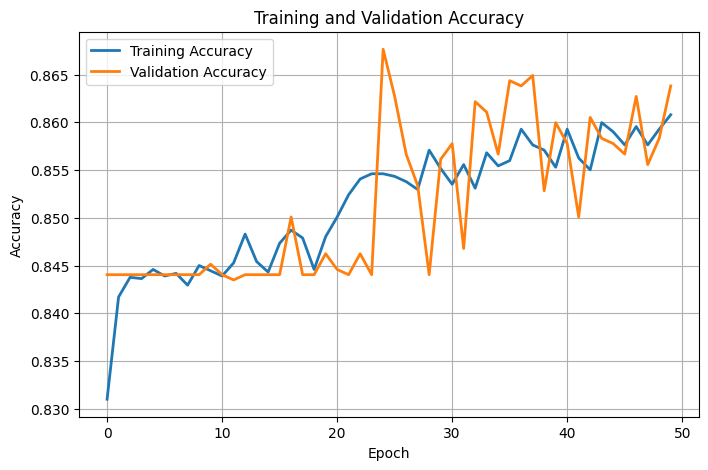

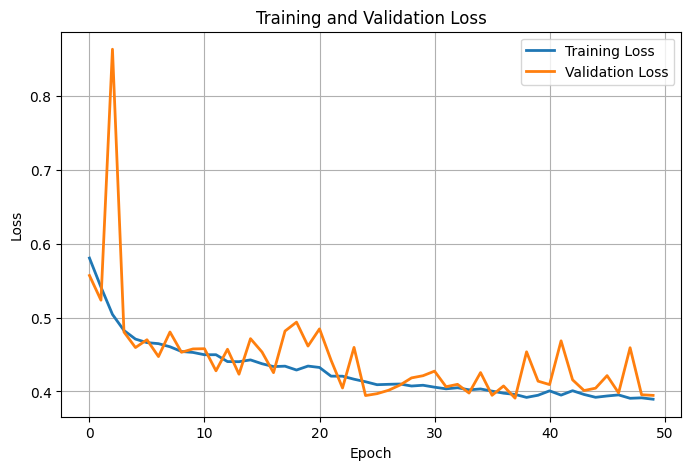

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [16]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Conv1D, MaxPooling1D, Flatten, Input, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE
import os

# 1. تحميل وتجهيز البيانات
df = pd.read_csv("colon and lung cancer dataset.csv")
cols = ['age', 'gender', 'dzgroup', 'num.co', 'diabetes', 'dementia', 'meanbp', 'wblc', 'hrt', 'resp', 
        'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlsc']
df = df[cols].copy()
df = df.dropna()

# ترميز الفئات
df['gender'] = LabelEncoder().fit_transform(df['gender'])
le_dz = LabelEncoder()
df['dzgroup'] = le_dz.fit_transform(df['dzgroup'])

X = df.drop('dzgroup', axis=1)
y = df['dzgroup']

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# القياس (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# معالجة عدم التوازن باستخدام SMOTE على بيانات التدريب فقط
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)

num_classes = len(np.unique(y))

# 2. تحسين نموذج MLP
def build_improved_mlp():
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(512, activation='swish'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(256, activation='swish'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='swish'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 3. تحسين نموذج 1D CNN
def build_improved_cnn():
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1], 1)),
        Conv1D(128, 3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv1D(128, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),
        
        Conv1D(256, 3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv1D(256, 3, padding='same', activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# الإضافات البرمجية (Callbacks)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

print("--- Training Improved MLP ---")
mlp = build_improved_mlp()
mlp.fit(X_resampled, y_resampled, validation_data=(X_test_scaled, y_test), 
        epochs=50, batch_size=64, callbacks=callbacks, verbose=0)
y_pred_mlp = np.argmax(mlp.predict(X_test_scaled), axis=1)
print("\nImproved MLP Results:")
print(classification_report(y_test, y_pred_mlp, target_names=le_dz.classes_))

print("\n--- Training Improved CNN ---")
cnn = build_improved_cnn()
X_res_cnn = X_resampled.reshape(X_resampled.shape[0], X_resampled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
cnn.fit(X_res_cnn, y_resampled, validation_data=(X_test_cnn, y_test), 
        epochs=50, batch_size=64, callbacks=callbacks, verbose=0)
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
print("\nImproved CNN Results:")
print(classification_report(y_test, y_pred_cnn, target_names=le_dz.classes_))


--- Training Improved MLP ---
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

Improved MLP Results:
              precision    recall  f1-score   support

Colon Cancer       0.23      0.47      0.31       102
 Lung Cancer       0.26      0.48      0.34       182
   No Cancer       0.94      0.78      0.85      1537

    accuracy                           0.73      1821
   macro avg       0.48      0.58      0.50      1821
weighted avg       0.83      0.73      0.77      1821


--- Training Improved CNN ---
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

Improved CNN Results:
              precision    recall  f1-score   support

Colon Cancer       0.00      0.00      0.00       102
 Lung Cancer       0.10      0.99      0.18       182
   No Cancer       0.96      0.01      0.03      1537

    accuracy                           0.11      1821
   macro avg       0.35      0.34      0.07      1821
weighted avg       0.82      0.11      0.04      1821



C:\Users\shahed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahed\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(